# 📊 ECG 2D CNN Model Benchmarking
This notebook evaluates 2D CNN models across different training strategies and dense layer sizes.

# 📥 Load and Prepare ECG Data

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load ECG .npz dataset from Google Drive
with np.load('/content/drive/MyDrive/ecg_dataset.npz') as loaded:
    X = loaded["x"]
    y = loaded["y"]

# Load ECG .npz dataset
#loaded = np.load("ecg_dataset.npz")
#X = loaded["x"]
#y = loaded["y"]

# Reshape for 2D CNN input (n_samples, 12, 5000, 1)
X = X.transpose(0, 2, 1)[..., np.newaxis]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"y_test  distribution: {np.bincount(y_test)}")


Mounted at /content/drive
X_train shape: (12085, 12, 5000, 1)
X_test shape : (3022, 12, 5000, 1)
y_train distribution: [7266 4819]
y_test  distribution: [1817 1205]


In [ ]:
!pip install imbalanced-learn


In [3]:
from sklearn.utils import class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('models/3-layers', exist_ok=True)

In [4]:

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

def build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=0.3, l2_strength=0.001, dense_units=64):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)


## ⚙️ Strategy: Base

### 🔩 Dense Units: 32

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6689 - f1: 0.4425 - loss: 1.2986 - precision_38: 0.7029 - recall_38: 0.3331
Epoch 1: val_f1 improved from -inf to 0.46732, saving model to models/3-layers/base_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.6689 - f1: 0.4425 - loss: 1.2975 - precision_38: 0.7032 - recall_38: 0.3330 - val_accuracy: 0.6832 - val_f1: 0.4673 - val_loss: 0.9324 - val_precision_38: 0.7241 - val_recall_38: 0.3450 - learning_rate: 0.0010
Epoch 2/100
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7326 - f1: 0.5093 - loss: 0.7020 - precision_38: 0.9040 - recall_38: 0.3585
Epoch 2: val_f1 improved from 0.46732 to 0.71042, saving model to models/3-layers/base_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7327 - f1: 0.5098 - loss: 0.7019 - precision_38: 0.9040 - recall_38: 0.3590 - val_accuracy: 0.8139 - val_f1: 0.7104 - val_loss: 0.6816 - val_precision_38: 0.9517 - val_recall_38: 0.5667 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8102 - f1: 0.7165 - loss: 0.6337 - precision_38: 0.8890 - recall_38: 0.6002
Epoch 3: val_f1 improved from 0.71042 to 0.82073, saving model to models/3-layers/base_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8103 - f1: 0.7166 - loss: 0.6339 - precision_38: 0.8888 - recall_38: 0.6004 - val_accuracy: 0.8627 - val_f1: 0.8207 - val_loss: 0.6003 - val_precision_38: 0.8656 - val_recall_38: 0.7803 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8447 - f1: 0.7874 - loss: 0.5917 - precision_38: 0.8763 - recall_38: 0.7149
Epoch 4: val_f1 did not improve from 0.82073
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8447 - f1: 0.7873 - loss: 0.5916 - precision_38: 0.8764 - recall_38: 0.7148 - val_accuracy: 0.8561 - val_f1: 0.8096 - val_loss: 0.5566 - val_precision_38: 0.8665 - val_recall_38: 0.7598 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8641 - f1: 0.8135 - loss: 0.5362 - precision_38: 0.8929 - recall_38: 0.7472
Epoch 5: val_f1 did not improve from 0.82073
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8639 - f1: 0.8133 - loss: 0.5367 -

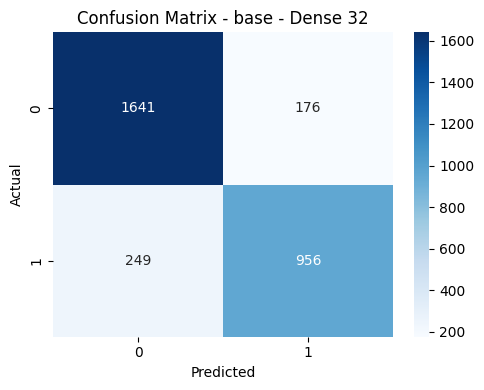

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: base, Dense: 32
dense_units = 32
strategy = "base"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/base_dense32_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: base | Dense: 32")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - base - Dense 32")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 🔩 Dense Units: 64

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6558 - f1: 0.4713 - loss: 1.3771 - precision_1: 0.5911 - recall_1: 0.4063
Epoch 1: val_f1 improved from -inf to 0.54725, saving model to models/3-layers/base_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.6559 - f1: 0.4717 - loss: 1.3760 - precision_1: 0.5914 - recall_1: 0.4068 - val_accuracy: 0.7345 - val_f1: 0.5472 - val_loss: 0.8903 - val_precision_1: 0.8739 - val_recall_1: 0.3984 - learning_rate: 0.0010
Epoch 2/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7956 - f1: 0.7166 - loss: 0.8181 - precision_1: 0.7993 - recall_1: 0.6525
Epoch 2: val_f1 improved from 0.54725 to 0.79916, saving model to models/3-layers/base_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7956 - f1: 0.7166 - loss: 0.8181 - precision_1: 0.7996 - recall_1: 0.6523 - val_accuracy: 0.8412 - val_f1: 0.7992 - val_loss: 0.7255 - val_precision_1: 0.8145 - val_recall_1: 0.7844 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8409 - f1: 0.7792 - loss: 0.6740 - precision_1: 0.8523 - recall_1: 0.7182
Epoch 3: val_f1 improved from 0.79916 to 0.80540, saving model to models/3-layers/base_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8409 - f1: 0.7793 - loss: 0.6737 - precision_1: 0.8525 - recall_1: 0.7181 - val_accuracy: 0.8569 - val_f1: 0.8054 - val_loss: 0.5675 - val_precision_1: 0.8905 - val_recall_1: 0.7351 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8601 - f1: 0.8117 - loss: 0.5446 - precision_1: 0.8736 - recall_1: 0.7583
Epoch 4: val_f1 did not improve from 0.80540
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8600 - f1: 0.8115 - loss: 0.5449 - precision_1: 0.8736 - recall_1: 0.7580 - val_accuracy: 0.8114 - val_f1: 0.7031 - val_loss: 0.7507 - val_precision_1: 0.9609 - val_recall_1: 0.5544 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8605 - f1: 0.8130 - loss: 0.6474 - precision_1: 0.8710 - recall_1: 0.7625
Epoch 5: val_f1 did not improve from 0.80540
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8604 - f1: 0.8128 - loss: 0.6486 - precision_1

340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8718 - f1: 0.8213 - loss: 0.6876 - precision_1: 0.8940 - recall_1: 0.7598 - val_accuracy: 0.8495 - val_f1: 0.8223 - val_loss: 0.6520 - val_precision_1: 0.7840 - val_recall_1: 0.8645 - learning_rate: 5.0000e-04
Epoch 7/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8883 - f1: 0.8493 - loss: 0.5061 - precision_1: 0.9018 - recall_1: 0.8029
Epoch 7: val_f1 did not improve from 0.82227
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8883 - f1: 0.8493 - loss: 0.5060 - precision_1: 0.9017 - recall_1: 0.8029 - val_accuracy: 0.8610 - val_f1: 0.8108 - val_loss: 0.5798 - val_precision_1: 0.8978 - val_recall_1: 0.7392 - learning_rate: 5.0000e-04
Epoch 8/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9087 - f1: 0.8799 - loss: 0.4040 - precision_1: 0.9259 - recall_1: 0.8382
Epoch 8: val_f1 improved from 0.82227 to 0.83480, saving model to models/3-layers/base_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9087 - f1: 0.8798 - loss: 0.4039 - precision_1: 0.9259 - recall_1: 0.8382 - val_accuracy: 0.8759 - val_f1: 0.8348 - val_loss: 0.5387 - val_precision_1: 0.9002 - val_recall_1: 0.7782 - learning_rate: 2.5000e-04
Epoch 9/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9323 - f1: 0.9128 - loss: 0.3414 - precision_1: 0.9447 - recall_1: 0.8831
Epoch 9: val_f1 did not improve from 0.83480
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9322 - f1: 0.9127 - loss: 0.3415 - precision_1: 0.9446 - recall_1: 0.8830 - val_accuracy: 0.8635 - val_f1: 0.8131 - val_loss: 0.5350 - val_precision_1: 0.9066 - val_recall_1: 0.7372 - learning_rate: 2.5000e-04
Epoch 10/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9449 - f1: 0.9286 - loss: 0.3002 - precision_1: 0.9486 - recall_1: 0.9096
Epoch 10: val_f1 did not improve from 0.83480
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9449 - f1: 0.9285 - loss: 0.3003 - p

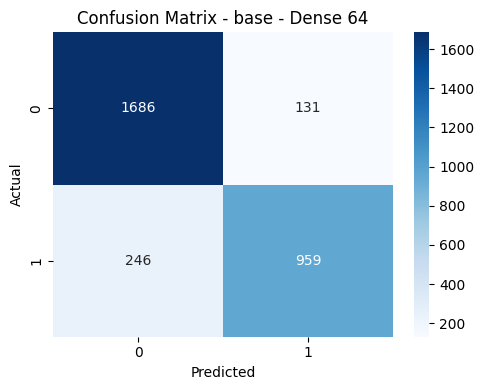

In [5]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: base, Dense: 64
dense_units = 64
strategy = "base"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/base_dense64_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: base | Dense: 64")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - base - Dense 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 128

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6316 - f1: 0.3623 - loss: 2.4784 - precision_3: 0.5907 - recall_3: 0.2708
Epoch 1: val_f1 improved from -inf to 0.28272, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.6318 - f1: 0.3627 - loss: 2.4750 - precision_3: 0.5911 - recall_3: 0.2711 - val_accuracy: 0.6600 - val_f1: 0.2827 - val_loss: 1.1888 - val_precision_3: 0.9419 - val_recall_3: 0.1663 - learning_rate: 0.0010
Epoch 2/100
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8000 - f1: 0.7118 - loss: 0.8253 - precision_3: 0.8356 - recall_3: 0.6202
Epoch 2: val_f1 improved from 0.28272 to 0.77622, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8000 - f1: 0.7118 - loss: 0.8253 - precision_3: 0.8356 - recall_3: 0.6203 - val_accuracy: 0.8412 - val_f1: 0.7762 - val_loss: 0.6823 - val_precision_3: 0.8976 - val_recall_3: 0.6838 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8440 - f1: 0.7862 - loss: 0.6943 - precision_3: 0.8626 - recall_3: 0.7224
Epoch 3: val_f1 did not improve from 0.77622
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8440 - f1: 0.7862 - loss: 0.6946 - precision_3: 0.8625 - recall_3: 0.7224 - val_accuracy: 0.8354 - val_f1: 0.7736 - val_loss: 0.8237 - val_precision_3: 0.8673 - val_recall_3: 0.6982 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8589 - f1: 0.8079 - loss: 0.7763 - precision_3: 0.8822 - recall_3: 0.7453
Epoch 4: val_f1 did not improve from 0.77622
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8588 - f1: 0.8078 - loss: 0.7764 - precision_3

340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8837 - f1: 0.8475 - loss: 0.6540 - precision_3: 0.8945 - recall_3: 0.8053 - val_accuracy: 0.8486 - val_f1: 0.7839 - val_loss: 0.6711 - val_precision_3: 0.9222 - val_recall_3: 0.6817 - learning_rate: 5.0000e-04
Epoch 6/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9032 - f1: 0.8703 - loss: 0.5525 - precision_3: 0.9166 - recall_3: 0.8286
Epoch 6: val_f1 improved from 0.78394 to 0.79577, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9031 - f1: 0.8701 - loss: 0.5527 - precision_3: 0.9164 - recall_3: 0.8285 - val_accuracy: 0.8561 - val_f1: 0.7958 - val_loss: 0.6759 - val_precision_3: 0.9288 - val_recall_3: 0.6961 - learning_rate: 5.0000e-04
Epoch 7/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9220 - f1: 0.8981 - loss: 0.4910 - precision_3: 0.9296 - recall_3: 0.8688
Epoch 7: val_f1 did not improve from 0.79577
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9220 - f1: 0.8980 - loss: 0.4912 - precision_3: 0.9295 - recall_3: 0.8687 - val_accuracy: 0.8230 - val_f1: 0.7270 - val_loss: 0.8320 - val_precision_3: 0.9596 - val_recall_3: 0.5852 - learning_rate: 5.0000e-04
Epoch 8/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9351 - f1: 0.9155 - loss: 0.4669 - precision_3: 0.9550 - recall_3: 0.8795
Epoch 8: val_f1 improved from 0.79577 to 0.79680, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9352 - f1: 0.9156 - loss: 0.4667 - precision_3: 0.9550 - recall_3: 0.8797 - val_accuracy: 0.8528 - val_f1: 0.7968 - val_loss: 0.7166 - val_precision_3: 0.8972 - val_recall_3: 0.7166 - learning_rate: 2.5000e-04
Epoch 9/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9610 - f1: 0.9504 - loss: 0.3622 - precision_3: 0.9704 - recall_3: 0.9312
Epoch 9: val_f1 did not improve from 0.79680
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9610 - f1: 0.9504 - loss: 0.3621 - precision_3: 0.9704 - recall_3: 0.9311 - val_accuracy: 0.8478 - val_f1: 0.7928 - val_loss: 0.7065 - val_precision_3: 0.8778 - val_recall_3: 0.7228 - learning_rate: 2.5000e-04
Epoch 10/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9740 - f1: 0.9667 - loss: 0.3085 - precision_3: 0.9794 - recall_3: 0.9543
Epoch 10: val_f1 improved from 0.79680 to 0.80744, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9740 - f1: 0.9667 - loss: 0.3084 - precision_3: 0.9794 - recall_3: 0.9543 - val_accuracy: 0.8544 - val_f1: 0.8074 - val_loss: 0.6651 - val_precision_3: 0.8642 - val_recall_3: 0.7577 - learning_rate: 1.2500e-04
Epoch 11/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9811 - f1: 0.9756 - loss: 0.2608 - precision_3: 0.9864 - recall_3: 0.9651
Epoch 11: val_f1 did not improve from 0.80744
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9811 - f1: 0.9756 - loss: 0.2608 - precision_3: 0.9864 - recall_3: 0.9651 - val_accuracy: 0.8586 - val_f1: 0.8055 - val_loss: 0.7188 - val_precision_3: 0.9031 - val_recall_3: 0.7269 - learning_rate: 1.2500e-04
Epoch 12/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9883 - f1: 0.9853 - loss: 0.2281 - precision_3: 0.9925 - recall_3: 0.9782
Epoch 12: val_f1 improved from 0.80744 to 0.82080, saving model to models/3-layers/base_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9883 - f1: 0.9853 - loss: 0.2281 - precision_3: 0.9925 - recall_3: 0.9782 - val_accuracy: 0.8660 - val_f1: 0.8208 - val_loss: 0.7162 - val_precision_3: 0.8897 - val_recall_3: 0.7618 - learning_rate: 1.2500e-04
Epoch 13/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9934 - f1: 0.9917 - loss: 0.2043 - precision_3: 0.9953 - recall_3: 0.9880
Epoch 13: val_f1 did not improve from 0.82080
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9934 - f1: 0.9916 - loss: 0.2043 - precision_3: 0.9953 - recall_3: 0.9880 - val_accuracy: 0.8644 - val_f1: 0.8198 - val_loss: 0.7036 - val_precision_3: 0.8818 - val_recall_3: 0.7659 - learning_rate: 6.2500e-05
Epoch 14/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9945 - f1: 0.9931 - loss: 0.1888 - precision_3: 0.9948 - recall_3: 0.9915
Epoch 14: val_f1 did not improve from 0.82080
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9945 - f1: 0.9931 - loss: 0.1888 -

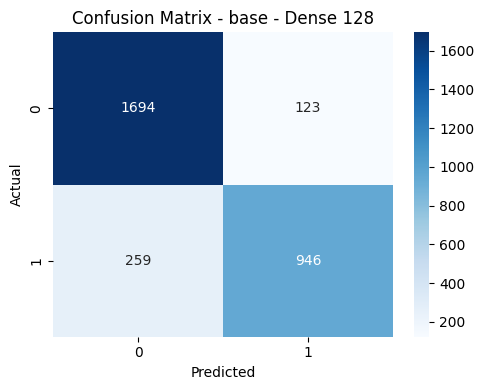

In [6]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: base, Dense: 128
dense_units = 128
strategy = "base"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/base_dense128_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: base | Dense: 128")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - base - Dense 128")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 256

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7284 - f1: 0.6365 - loss: 2.5632 - precision_10: 0.6902 - recall_10: 0.5922
Epoch 1: val_f1 improved from -inf to 0.53216, saving model to models/3-layers/base_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.7285 - f1: 0.6367 - loss: 2.5603 - precision_10: 0.6904 - recall_10: 0.5923 - val_accuracy: 0.7353 - val_f1: 0.5322 - val_loss: 1.1427 - val_precision_10: 0.9239 - val_recall_10: 0.3737 - learning_rate: 0.0010
Epoch 2/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8388 - f1: 0.7814 - loss: 0.9450 - precision_10: 0.8567 - recall_10: 0.7183
Epoch 2: val_f1 improved from 0.53216 to 0.74548, saving model to models/3-layers/base_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8387 - f1: 0.7813 - loss: 0.9453 - precision_10: 0.8566 - recall_10: 0.7182 - val_accuracy: 0.8255 - val_f1: 0.7455 - val_loss: 0.9510 - val_precision_10: 0.9035 - val_recall_10: 0.6345 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8405 - f1: 0.7828 - loss: 1.0249 - precision_10: 0.8445 - recall_10: 0.7298
Epoch 3: val_f1 improved from 0.74548 to 0.80815, saving model to models/3-layers/base_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8405 - f1: 0.7829 - loss: 1.0245 - precision_10: 0.8446 - recall_10: 0.7299 - val_accuracy: 0.8519 - val_f1: 0.8081 - val_loss: 0.9215 - val_precision_10: 0.8453 - val_recall_10: 0.7741 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8600 - f1: 0.8153 - loss: 0.9848 - precision_10: 0.8603 - recall_10: 0.7750
Epoch 4: val_f1 improved from 0.80815 to 0.80816, saving model to models/3-layers/base_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8600 - f1: 0.8153 - loss: 0.9854 - precision_10: 0.8602 - recall_10: 0.7749 - val_accuracy: 0.8445 - val_f1: 0.8082 - val_loss: 0.9853 - val_precision_10: 0.8032 - val_recall_10: 0.8131 - learning_rate: 0.0010
Epoch 5/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8707 - f1: 0.8264 - loss: 0.9627 - precision_10: 0.8713 - recall_10: 0.7860
Epoch 5: val_f1 did not improve from 0.80816
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8707 - f1: 0.8264 - loss: 0.9627 - precision_10: 0.8713 - recall_10: 0.7860 - val_accuracy: 0.8437 - val_f1: 0.7784 - val_loss: 0.9665 - val_precision_10: 0.9071 - val_recall_10: 0.6817 - learning_rate: 0.0010
Epoch 6/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9041 - f1: 0.8724 - loss: 0.7721 - precision_10: 0.9149 - recall_10: 0.8339
Epoch 6: val_f1 did not improve from 0.80816
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9041 - f1: 0.8724 - loss: 0.7719 -

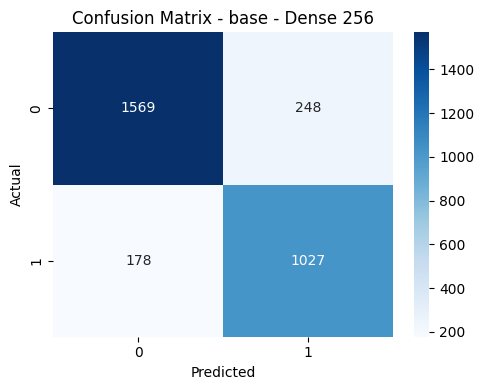

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: base, Dense: 256
dense_units = 256
strategy = "base"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/base_dense256_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: base | Dense: 256")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - base - Dense 256")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ⚙️ Strategy: Weighted

### 🔩 Dense Units: 32

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6493 - f1: 0.5461 - loss: 1.1800 - precision_12: 0.5665 - recall_12: 0.5342
Epoch 1: val_f1 improved from -inf to 0.44168, saving model to models/3-layers/weighted_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.6495 - f1: 0.5462 - loss: 1.1791 - precision_12: 0.5667 - recall_12: 0.5342 - val_accuracy: 0.7031 - val_f1: 0.4417 - val_loss: 0.7803 - val_precision_12: 0.9103 - val_recall_12: 0.2916 - learning_rate: 0.0010
Epoch 2/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7686 - f1: 0.6636 - loss: 0.7066 - precision_12: 0.7891 - recall_12: 0.5730
Epoch 2: val_f1 improved from 0.44168 to 0.79109, saving model to models/3-layers/weighted_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7687 - f1: 0.6638 - loss: 0.7065 - precision_12: 0.7893 - recall_12: 0.5732 - val_accuracy: 0.8371 - val_f1: 0.7911 - val_loss: 0.7202 - val_precision_12: 0.8180 - val_recall_12: 0.7659 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7991 - f1: 0.7079 - loss: 0.7067 - precision_12: 0.8365 - recall_12: 0.6144
Epoch 3: val_f1 improved from 0.79109 to 0.80462, saving model to models/3-layers/weighted_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7993 - f1: 0.7082 - loss: 0.7065 - precision_12: 0.8366 - recall_12: 0.6148 - val_accuracy: 0.8462 - val_f1: 0.8046 - val_loss: 0.5999 - val_precision_12: 0.8237 - val_recall_12: 0.7864 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8458 - f1: 0.7948 - loss: 0.6241 - precision_12: 0.8518 - recall_12: 0.7454
Epoch 4: val_f1 improved from 0.80462 to 0.81437, saving model to models/3-layers/weighted_dense32_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8457 - f1: 0.7947 - loss: 0.6241 - precision_12: 0.8518 - recall_12: 0.7451 - val_accuracy: 0.8462 - val_f1: 0.8144 - val_loss: 0.6138 - val_precision_12: 0.7922 - val_recall_12: 0.8378 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8487 - f1: 0.7969 - loss: 0.5883 - precision_12: 0.8554 - recall_12: 0.7465
Epoch 5: val_f1 did not improve from 0.81437
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8487 - f1: 0.7969 - loss: 0.5882 - precision_12: 0.8555 - recall_12: 0.7464 - val_accuracy: 0.8553 - val_f1: 0.7948 - val_loss: 0.5460 - val_precision_12: 0.9262 - val_recall_12: 0.6961 - learning_rate: 0.0010
Epoch 6/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8692 - f1: 0.8233 - loss: 0.5210 - precision_12: 0.8836 - recall_12: 0.7713
Epoch 6: val_f1 did not improve from 0.81437
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8691 - f1: 0.8231 - loss: 0.5213 -

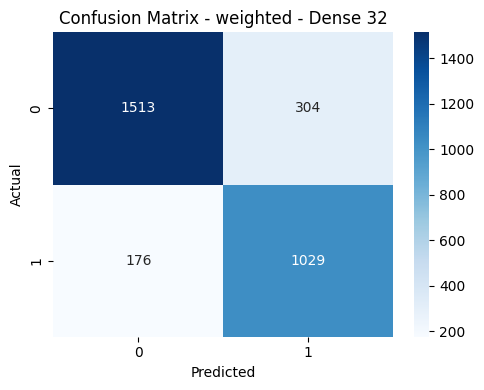

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: weighted, Dense: 32
dense_units = 32
strategy = "weighted"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/weighted_dense32_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: weighted | Dense: 32")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - weighted - Dense 32")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 64

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7070 - f1: 0.6544 - loss: 1.3463 - precision_14: 0.6222 - recall_14: 0.6946
Epoch 1: val_f1 improved from -inf to 0.76451, saving model to models/3-layers/weighted_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7072 - f1: 0.6545 - loss: 1.3452 - precision_14: 0.6224 - recall_14: 0.6946 - val_accuracy: 0.8222 - val_f1: 0.7645 - val_loss: 0.7733 - val_precision_14: 0.8192 - val_recall_14: 0.7166 - learning_rate: 0.0010
Epoch 2/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8316 - f1: 0.7867 - loss: 0.7362 - precision_14: 0.8132 - recall_14: 0.7621
Epoch 2: val_f1 improved from 0.76451 to 0.76676, saving model to models/3-layers/weighted_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8316 - f1: 0.7866 - loss: 0.7365 - precision_14: 0.8133 - recall_14: 0.7620 - val_accuracy: 0.7957 - val_f1: 0.7668 - val_loss: 0.8249 - val_precision_14: 0.7098 - val_recall_14: 0.8337 - learning_rate: 0.0010
Epoch 3/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8402 - f1: 0.7890 - loss: 0.7217 - precision_14: 0.8159 - recall_14: 0.7641
Epoch 3: val_f1 improved from 0.76676 to 0.78795, saving model to models/3-layers/weighted_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8402 - f1: 0.7890 - loss: 0.7216 - precision_14: 0.8160 - recall_14: 0.7641 - val_accuracy: 0.8486 - val_f1: 0.7879 - val_loss: 0.6171 - val_precision_14: 0.9043 - val_recall_14: 0.6982 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8524 - f1: 0.8058 - loss: 0.6540 - precision_14: 0.8413 - recall_14: 0.7735
Epoch 4: val_f1 did not improve from 0.78795
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8523 - f1: 0.8058 - loss: 0.6542 - precision_14: 0.8412 - recall_14: 0.7736 - val_accuracy: 0.8362 - val_f1: 0.7568 - val_loss: 0.6734 - val_precision_14: 0.9419 - val_recall_14: 0.6324 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8743 - f1: 0.8374 - loss: 0.6338 - precision_14: 0.8541 - recall_14: 0.8217
Epoch 5: val_f1 improved from 0.78795 to 0.80645, saving model to models/3-layers/weighted_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8742 - f1: 0.8373 - loss: 0.6340 - precision_14: 0.8540 - recall_14: 0.8215 - val_accuracy: 0.8412 - val_f1: 0.8065 - val_loss: 0.6723 - val_precision_14: 0.7921 - val_recall_14: 0.8214 - learning_rate: 0.0010
Epoch 6/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8915 - f1: 0.8582 - loss: 0.5421 - precision_14: 0.8741 - recall_14: 0.8430
Epoch 6: val_f1 improved from 0.80645 to 0.83351, saving model to models/3-layers/weighted_dense64_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8915 - f1: 0.8583 - loss: 0.5419 - precision_14: 0.8742 - recall_14: 0.8431 - val_accuracy: 0.8718 - val_f1: 0.8335 - val_loss: 0.5550 - val_precision_14: 0.8739 - val_recall_14: 0.7967 - learning_rate: 5.0000e-04
Epoch 7/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9104 - f1: 0.8848 - loss: 0.4403 - precision_14: 0.9045 - recall_14: 0.8661
Epoch 7: val_f1 did not improve from 0.83351
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9103 - f1: 0.8848 - loss: 0.4404 - precision_14: 0.9044 - recall_14: 0.8661 - val_accuracy: 0.8536 - val_f1: 0.8173 - val_loss: 0.5801 - val_precision_14: 0.8216 - val_recall_14: 0.8131 - learning_rate: 5.0000e-04
Epoch 8/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9240 - f1: 0.9054 - loss: 0.4068 - precision_14: 0.9100 - recall_14: 0.9010
Epoch 8: val_f1 did not improve from 0.83351
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9240 - f1: 0.9054 - loss: 

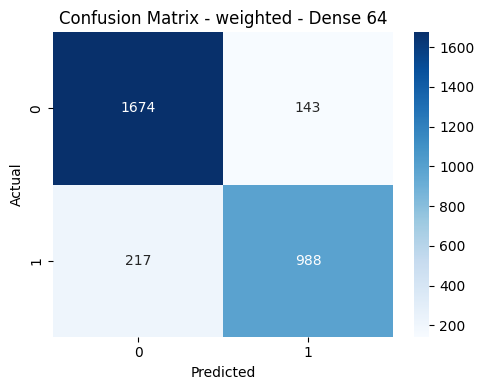

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: weighted, Dense: 64
dense_units = 64
strategy = "weighted"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/weighted_dense64_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: weighted | Dense: 64")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - weighted - Dense 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 128

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7087 - f1: 0.6432 - loss: 2.0564 - precision_16: 0.6173 - recall_16: 0.6720
Epoch 1: val_f1 improved from -inf to 0.58689, saving model to models/3-layers/weighted_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7088 - f1: 0.6434 - loss: 2.0542 - precision_16: 0.6175 - recall_16: 0.6721 - val_accuracy: 0.7601 - val_f1: 0.5869 - val_loss: 1.0015 - val_precision_16: 0.9581 - val_recall_16: 0.4230 - learning_rate: 0.0010
Epoch 2/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8236 - f1: 0.7771 - loss: 0.8661 - precision_16: 0.7708 - recall_16: 0.7837
Epoch 2: val_f1 improved from 0.58689 to 0.80571, saving model to models/3-layers/weighted_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8236 - f1: 0.7772 - loss: 0.8660 - precision_16: 0.7708 - recall_16: 0.7838 - val_accuracy: 0.8536 - val_f1: 0.8057 - val_loss: 0.7391 - val_precision_16: 0.8656 - val_recall_16: 0.7536 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8629 - f1: 0.8258 - loss: 0.7301 - precision_16: 0.8392 - recall_16: 0.8130
Epoch 3: val_f1 improved from 0.80571 to 0.81136, saving model to models/3-layers/weighted_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8627 - f1: 0.8256 - loss: 0.7305 - precision_16: 0.8390 - recall_16: 0.8129 - val_accuracy: 0.8627 - val_f1: 0.8114 - val_loss: 0.8217 - val_precision_16: 0.9084 - val_recall_16: 0.7331 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8655 - f1: 0.8338 - loss: 0.8019 - precision_16: 0.8312 - recall_16: 0.8365
Epoch 4: val_f1 did not improve from 0.81136
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8654 - f1: 0.8336 - loss: 0.8024 - precision_16: 0.8311 - recall_16: 0.8362 - val_accuracy: 0.8362 - val_f1: 0.7637 - val_loss: 0.8337 - val_precision_16: 0.9117 - val_recall_16: 0.6571 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8870 - f1: 0.8554 - loss: 0.7065 - precision_16: 0.8610 - recall_16: 0.8500
Epoch 5: val_f1 improved from 0.81136 to 0.81728, saving model to models/3-layers/weighted_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8870 - f1: 0.8555 - loss: 0.7060 - precision_16: 0.8611 - recall_16: 0.8501 - val_accuracy: 0.8635 - val_f1: 0.8173 - val_loss: 0.6825 - val_precision_16: 0.8870 - val_recall_16: 0.7577 - learning_rate: 5.0000e-04
Epoch 6/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9131 - f1: 0.8899 - loss: 0.5584 - precision_16: 0.8896 - recall_16: 0.8902
Epoch 6: val_f1 improved from 0.81728 to 0.81855, saving model to models/3-layers/weighted_dense128_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9130 - f1: 0.8898 - loss: 0.5585 - precision_16: 0.8895 - recall_16: 0.8901 - val_accuracy: 0.8511 - val_f1: 0.8185 - val_loss: 0.6925 - val_precision_16: 0.8040 - val_recall_16: 0.8337 - learning_rate: 5.0000e-04
Epoch 7/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9247 - f1: 0.9069 - loss: 0.5144 - precision_16: 0.8980 - recall_16: 0.9161
Epoch 7: val_f1 did not improve from 0.81855
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9247 - f1: 0.9069 - loss: 0.5145 - precision_16: 0.8980 - recall_16: 0.9160 - val_accuracy: 0.8553 - val_f1: 0.8112 - val_loss: 0.7457 - val_precision_16: 0.8545 - val_recall_16: 0.7721 - learning_rate: 5.0000e-04
Epoch 8/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9521 - f1: 0.9388 - loss: 0.4359 - precision_16: 0.9395 - recall_16: 0.9382
Epoch 8: val_f1 did not improve from 0.81855
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9521 - f1: 0.9389 - loss: 

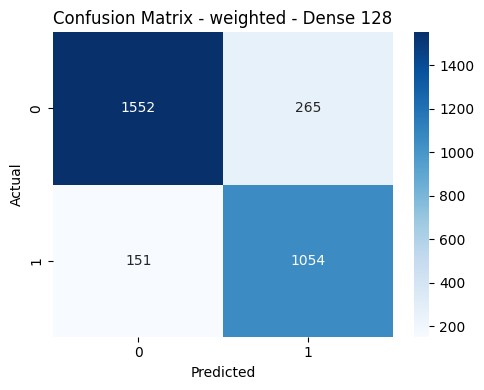

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: weighted, Dense: 128
dense_units = 128
strategy = "weighted"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/weighted_dense128_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: weighted | Dense: 128")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - weighted - Dense 128")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 256

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6192 - f1: 0.4978 - loss: 4.3495 - precision_18: 0.5251 - recall_18: 0.4835
Epoch 1: val_f1 improved from -inf to 0.48296, saving model to models/3-layers/weighted_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.6194 - f1: 0.4982 - loss: 4.3426 - precision_18: 0.5254 - recall_18: 0.4838 - val_accuracy: 0.7113 - val_f1: 0.4830 - val_loss: 4.2223 - val_precision_18: 0.8670 - val_recall_18: 0.3347 - learning_rate: 0.0010
Epoch 2/100
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7891 - f1: 0.7422 - loss: 1.0199 - precision_18: 0.7319 - recall_18: 0.7531
Epoch 2: val_f1 improved from 0.48296 to 0.77912, saving model to models/3-layers/weighted_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7892 - f1: 0.7423 - loss: 1.0194 - precision_18: 0.7320 - recall_18: 0.7532 - val_accuracy: 0.8180 - val_f1: 0.7791 - val_loss: 0.7789 - val_precision_18: 0.7623 - val_recall_18: 0.7967 - learning_rate: 0.0010
Epoch 3/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8266 - f1: 0.7845 - loss: 0.7371 - precision_18: 0.7690 - recall_18: 0.8010
Epoch 3: val_f1 improved from 0.77912 to 0.81425, saving model to models/3-layers/weighted_dense256_best_model.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8266 - f1: 0.7846 - loss: 0.7370 - precision_18: 0.7690 - recall_18: 0.8010 - val_accuracy: 0.8577 - val_f1: 0.8143 - val_loss: 0.7259 - val_precision_18: 0.8588 - val_recall_18: 0.7741 - learning_rate: 0.0010
Epoch 4/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8526 - f1: 0.8135 - loss: 0.7892 - precision_18: 0.8242 - recall_18: 0.8033
Epoch 4: val_f1 did not improve from 0.81425
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8525 - f1: 0.8134 - loss: 0.7899 - precision_18: 0.8240 - recall_18: 0.8032 - val_accuracy: 0.8519 - val_f1: 0.8102 - val_loss: 0.7918 - val_precision_18: 0.8377 - val_recall_18: 0.7844 - learning_rate: 0.0010
Epoch 5/100
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8636 - f1: 0.8264 - loss: 0.7719 - precision_18: 0.8353 - recall_18: 0.8180
Epoch 5: val_f1 did not improve from 0.81425
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8635 - f1: 0.8263 - loss: 0.7736 -

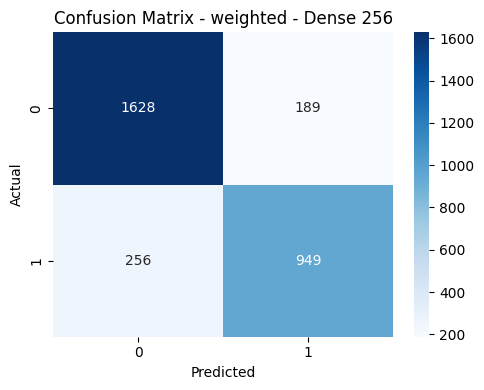

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: weighted, Dense: 256
dense_units = 256
strategy = "weighted"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/weighted_dense256_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: weighted | Dense: 256")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - weighted - Dense 256")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ⚙️ Strategy: Oversample

### 🔩 Dense Units: 32

Epoch 1/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6721 - f1: 0.5631 - loss: 1.1497 - precision_20: 0.6978 - recall_20: 0.4762
Epoch 1: val_f1 improved from -inf to 0.79785, saving model to models/3-layers/oversampling_dense32_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6722 - f1: 0.5632 - loss: 1.1490 - precision_20: 0.6980 - recall_20: 0.4762 - val_accuracy: 0.6637 - val_f1: 0.7979 - val_loss: 0.7819 - val_precision_20: 1.0000 - val_recall_20: 0.6637 - learning_rate: 0.0010
Epoch 2/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7826 - f1: 0.7184 - loss: 0.6701 - precision_20: 0.8609 - recall_20: 0.6167
Epoch 2: val_f1 improved from 0.79785 to 0.87635, saving model to models/3-layers/oversampling_dense32_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7826 - f1: 0.7185 - loss: 0.6701 - precision_20: 0.8609 - recall_20: 0.6168 - val_accuracy: 0.7799 - val_f1: 0.8764 - val_loss: 0.5488 - val_precision_20: 1.0000 - val_recall_20: 0.7799 - learning_rate: 0.0010
Epoch 3/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8241 - f1: 0.7753 - loss: 0.6046 - precision_20: 0.8746 - recall_20: 0.6965
Epoch 3: val_f1 did not improve from 0.87635
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8241 - f1: 0.7753 - loss: 0.6046 - precision_20: 0.8746 - recall_20: 0.6965 - val_accuracy: 0.7008 - val_f1: 0.8241 - val_loss: 0.7383 - val_precision_20: 1.0000 - val_recall_20: 0.7008 - learning_rate: 0.0010
Epoch 4/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8325 - f1: 0.7887 - loss: 0.6212 - precision_20: 0.8969 - recall_20: 0.7040
Epoch 4: val_f1 improved from 0.87635 to 0.89598, saving model to models/3-layers/oversampling_dense32_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8325 - f1: 0.7887 - loss: 0.6212 - precision_20: 0.8969 - recall_20: 0.7040 - val_accuracy: 0.8116 - val_f1: 0.8960 - val_loss: 0.5045 - val_precision_20: 1.0000 - val_recall_20: 0.8116 - learning_rate: 0.0010
Epoch 5/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - f1: 0.8172 - loss: 0.5664 - precision_20: 0.9017 - recall_20: 0.7473
Epoch 5: val_f1 did not improve from 0.89598
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8500 - f1: 0.8172 - loss: 0.5664 - precision_20: 0.9017 - recall_20: 0.7474 - val_accuracy: 0.7785 - val_f1: 0.8755 - val_loss: 0.5895 - val_precision_20: 1.0000 - val_recall_20: 0.7785 - learning_rate: 0.0010
Epoch 6/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8640 - f1: 0.8335 - loss: 0.5530 - precision_20: 0.9077 - recall_20: 0.7708
Epoch 6: val_f1 improved from 0.89598 to 0.93869, saving model to models/3-layers/oversampling_dense32_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8640 - f1: 0.8335 - loss: 0.5531 - precision_20: 0.9077 - recall_20: 0.7707 - val_accuracy: 0.8845 - val_f1: 0.9387 - val_loss: 0.4780 - val_precision_20: 1.0000 - val_recall_20: 0.8845 - learning_rate: 0.0010
Epoch 7/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8766 - f1: 0.8536 - loss: 0.5283 - precision_20: 0.9088 - recall_20: 0.8047
Epoch 7: val_f1 improved from 0.93869 to 0.96549, saving model to models/3-layers/oversampling_dense32_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8766 - f1: 0.8535 - loss: 0.5283 - precision_20: 0.9088 - recall_20: 0.8047 - val_accuracy: 0.9333 - val_f1: 0.9655 - val_loss: 0.3775 - val_precision_20: 1.0000 - val_recall_20: 0.9333 - learning_rate: 0.0010
Epoch 8/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8813 - f1: 0.8602 - loss: 0.5302 - precision_20: 0.9122 - recall_20: 0.8139
Epoch 8: val_f1 did not improve from 0.96549
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8813 - f1: 0.8602 - loss: 0.5302 - precision_20: 0.9122 - recall_20: 0.8139 - val_accuracy: 0.7944 - val_f1: 0.8854 - val_loss: 0.6376 - val_precision_20: 1.0000 - val_recall_20: 0.7944 - learning_rate: 0.0010
Epoch 9/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8860 - f1: 0.8653 - loss: 0.5651 - precision_20: 0.9168 - recall_20: 0.8194
Epoch 9: val_f1 did not improve from 0.96549
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8860 - f1: 0.8653 - loss: 0.5651 -

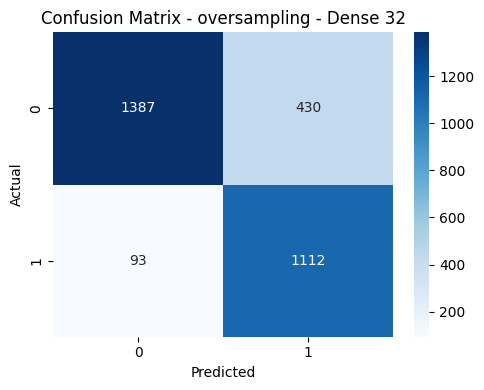

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: oversample, Dense: 32
dense_units = 32
strategy = "oversample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/oversampling_dense32_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: oversampling | Dense: 32")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - oversampling - Dense 32")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 64

Epoch 1/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6403 - f1: 0.4951 - loss: 1.7218 - precision_22: 0.6607 - recall_22: 0.3992
Epoch 1: val_f1 improved from -inf to 0.73345, saving model to models/3-layers/oversampling_dense64_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6405 - f1: 0.4953 - loss: 1.7203 - precision_22: 0.6610 - recall_22: 0.3994 - val_accuracy: 0.5791 - val_f1: 0.7334 - val_loss: 1.0497 - val_precision_22: 1.0000 - val_recall_22: 0.5791 - learning_rate: 0.0010
Epoch 2/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7899 - f1: 0.7273 - loss: 0.7195 - precision_22: 0.8726 - recall_22: 0.6237
Epoch 2: val_f1 improved from 0.73345 to 0.78580, saving model to models/3-layers/oversampling_dense64_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7900 - f1: 0.7274 - loss: 0.7195 - precision_22: 0.8725 - recall_22: 0.6238 - val_accuracy: 0.6472 - val_f1: 0.7858 - val_loss: 0.7518 - val_precision_22: 1.0000 - val_recall_22: 0.6472 - learning_rate: 0.0010
Epoch 3/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8214 - f1: 0.7726 - loss: 0.6315 - precision_22: 0.8826 - recall_22: 0.6873
Epoch 3: val_f1 improved from 0.78580 to 0.83819, saving model to models/3-layers/oversampling_dense64_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8214 - f1: 0.7726 - loss: 0.6315 - precision_22: 0.8826 - recall_22: 0.6873 - val_accuracy: 0.7215 - val_f1: 0.8382 - val_loss: 0.7268 - val_precision_22: 1.0000 - val_recall_22: 0.7215 - learning_rate: 0.0010
Epoch 4/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8317 - f1: 0.7890 - loss: 0.6390 - precision_22: 0.8874 - recall_22: 0.7103
Epoch 4: val_f1 improved from 0.83819 to 0.89430, saving model to models/3-layers/oversampling_dense64_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8317 - f1: 0.7890 - loss: 0.6390 - precision_22: 0.8874 - recall_22: 0.7103 - val_accuracy: 0.8088 - val_f1: 0.8943 - val_loss: 0.5741 - val_precision_22: 1.0000 - val_recall_22: 0.8088 - learning_rate: 0.0010
Epoch 5/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8538 - f1: 0.8208 - loss: 0.6226 - precision_22: 0.8979 - recall_22: 0.7561
Epoch 5: val_f1 improved from 0.89430 to 0.95207, saving model to models/3-layers/oversampling_dense64_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8538 - f1: 0.8208 - loss: 0.6226 - precision_22: 0.8979 - recall_22: 0.7561 - val_accuracy: 0.9085 - val_f1: 0.9521 - val_loss: 0.5023 - val_precision_22: 1.0000 - val_recall_22: 0.9085 - learning_rate: 0.0010
Epoch 6/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8717 - f1: 0.8496 - loss: 0.6046 - precision_22: 0.8945 - recall_22: 0.8094
Epoch 6: val_f1 did not improve from 0.95207
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8717 - f1: 0.8496 - loss: 0.6046 - precision_22: 0.8945 - recall_22: 0.8093 - val_accuracy: 0.8377 - val_f1: 0.9117 - val_loss: 0.5957 - val_precision_22: 1.0000 - val_recall_22: 0.8377 - learning_rate: 0.0010
Epoch 7/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8847 - f1: 0.8643 - loss: 0.5471 - precision_22: 0.9030 - recall_22: 0.8291
Epoch 7: val_f1 did not improve from 0.95207
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8847 - f1: 0.8643 - loss: 0.5471 -

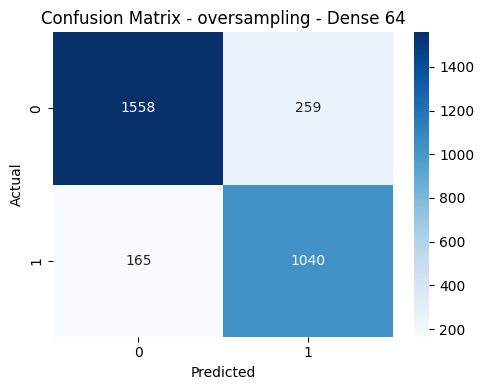

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: oversample, Dense: 64
dense_units = 64
strategy = "oversample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/oversampling_dense64_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: oversampling | Dense: 64")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - oversampling - Dense 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 128

Epoch 1/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7219 - f1: 0.6622 - loss: 2.0210 - precision_24: 0.7164 - recall_24: 0.6167
Epoch 1: val_f1 improved from -inf to 0.69888, saving model to models/3-layers/oversampling_dense128_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7220 - f1: 0.6624 - loss: 2.0191 - precision_24: 0.7165 - recall_24: 0.6169 - val_accuracy: 0.5371 - val_f1: 0.6989 - val_loss: 1.3461 - val_precision_24: 1.0000 - val_recall_24: 0.5371 - learning_rate: 0.0010
Epoch 2/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8354 - f1: 0.8072 - loss: 0.7951 - precision_24: 0.8533 - recall_24: 0.7662
Epoch 2: val_f1 improved from 0.69888 to 0.87461, saving model to models/3-layers/oversampling_dense128_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8354 - f1: 0.8071 - loss: 0.7951 - precision_24: 0.8533 - recall_24: 0.7662 - val_accuracy: 0.7772 - val_f1: 0.8746 - val_loss: 0.9589 - val_precision_24: 1.0000 - val_recall_24: 0.7772 - learning_rate: 0.0010
Epoch 3/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8479 - f1: 0.8186 - loss: 0.7836 - precision_24: 0.8677 - recall_24: 0.7751
Epoch 3: val_f1 improved from 0.87461 to 0.95396, saving model to models/3-layers/oversampling_dense128_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8479 - f1: 0.8187 - loss: 0.7835 - precision_24: 0.8677 - recall_24: 0.7751 - val_accuracy: 0.9120 - val_f1: 0.9540 - val_loss: 0.5368 - val_precision_24: 1.0000 - val_recall_24: 0.9120 - learning_rate: 0.0010
Epoch 4/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8603 - f1: 0.8375 - loss: 0.7163 - precision_24: 0.8688 - recall_24: 0.8087
Epoch 4: val_f1 did not improve from 0.95396
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8603 - f1: 0.8375 - loss: 0.7165 - precision_24: 0.8688 - recall_24: 0.8087 - val_accuracy: 0.7077 - val_f1: 0.8288 - val_loss: 0.9527 - val_precision_24: 1.0000 - val_recall_24: 0.7077 - learning_rate: 0.0010
Epoch 5/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8815 - f1: 0.8632 - loss: 0.7226 - precision_24: 0.8958 - recall_24: 0.8330
Epoch 5: val_f1 did not improve from 0.95396
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8815 - f1: 0.8632 - loss: 0.7227 -

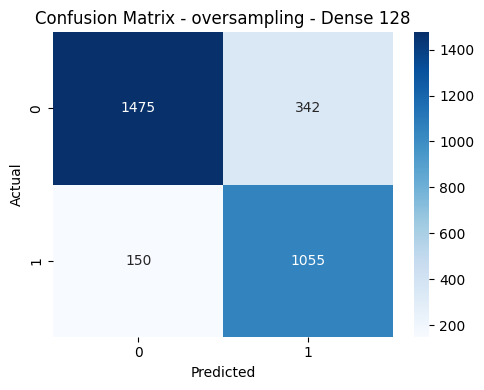

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: oversample, Dense: 128
dense_units = 128
strategy = "oversample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/oversampling_dense128_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: oversampling | Dense: 128")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - oversampling - Dense 128")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 256

Epoch 1/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7172 - f1: 0.6614 - loss: 3.0763 - precision_26: 0.7056 - recall_26: 0.6230
Epoch 1: val_f1 improved from -inf to 0.79735, saving model to models/3-layers/oversampling_dense256_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7173 - f1: 0.6616 - loss: 3.0728 - precision_26: 0.7058 - recall_26: 0.6232 - val_accuracy: 0.6630 - val_f1: 0.7974 - val_loss: 1.4144 - val_precision_26: 1.0000 - val_recall_26: 0.6630 - learning_rate: 0.0010
Epoch 2/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8370 - f1: 0.8094 - loss: 0.8719 - precision_26: 0.8574 - recall_26: 0.7668
Epoch 2: val_f1 improved from 0.79735 to 0.95696, saving model to models/3-layers/oversampling_dense256_best_model.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8370 - f1: 0.8094 - loss: 0.8720 - precision_26: 0.8574 - recall_26: 0.7668 - val_accuracy: 0.9175 - val_f1: 0.9570 - val_loss: 0.8699 - val_precision_26: 1.0000 - val_recall_26: 0.9175 - learning_rate: 0.0010
Epoch 3/100
408/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8462 - f1: 0.8179 - loss: 1.0323 - precision_26: 0.8613 - recall_26: 0.7789
Epoch 3: val_f1 did not improve from 0.95696
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8463 - f1: 0.8180 - loss: 1.0319 - precision_26: 0.8613 - recall_26: 0.7790 - val_accuracy: 0.9030 - val_f1: 0.9490 - val_loss: 0.6483 - val_precision_26: 1.0000 - val_recall_26: 0.9030 - learning_rate: 0.0010
Epoch 4/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8680 - f1: 0.8467 - loss: 0.8316 - precision_26: 0.8813 - recall_26: 0.8148
Epoch 4: val_f1 did not improve from 0.95696
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8680 - f1: 0.8467 - loss: 0.8318 -

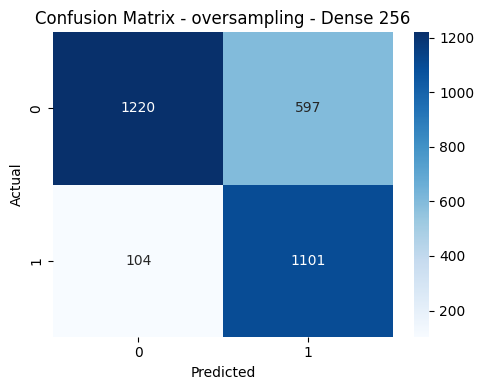

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: oversample, Dense: 256
dense_units = 256
strategy = "oversample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/oversampling_dense256_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: oversampling | Dense: 256")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - oversampling - Dense 256")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ⚙️ Strategy: Undersample

### 🔩 Dense Units: 32

Epoch 1/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6774 - f1: 0.5736 - loss: 1.0761 - precision_28: 0.7175 - recall_28: 0.4819
Epoch 1: val_f1 improved from -inf to 0.86052, saving model to models/3-layers/undersampling_dense32_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.6775 - f1: 0.5738 - loss: 1.0754 - precision_28: 0.7177 - recall_28: 0.4820 - val_accuracy: 0.7552 - val_f1: 0.8605 - val_loss: 0.8332 - val_precision_28: 1.0000 - val_recall_28: 0.7552 - learning_rate: 0.0010
Epoch 2/100
268/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7899 - f1: 0.7335 - loss: 0.7144 - precision_28: 0.8576 - recall_28: 0.6412
Epoch 2: val_f1 improved from 0.86052 to 0.93598, saving model to models/3-layers/undersampling_dense32_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7901 - f1: 0.7338 - loss: 0.7139 - precision_28: 0.8575 - recall_28: 0.6416 - val_accuracy: 0.8797 - val_f1: 0.9360 - val_loss: 0.4570 - val_precision_28: 1.0000 - val_recall_28: 0.8797 - learning_rate: 0.0010
Epoch 3/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8305 - f1: 0.7918 - loss: 0.6012 - precision_28: 0.8644 - recall_28: 0.7308
Epoch 3: val_f1 did not improve from 0.93598
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8305 - f1: 0.7918 - loss: 0.6011 - precision_28: 0.8644 - recall_28: 0.7308 - val_accuracy: 0.6286 - val_f1: 0.7720 - val_loss: 0.9370 - val_precision_28: 1.0000 - val_recall_28: 0.6286 - learning_rate: 0.0010
Epoch 4/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8434 - f1: 0.8098 - loss: 0.5956 - precision_28: 0.8789 - recall_28: 0.7513
Epoch 4: val_f1 did not improve from 0.93598
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8433 - f1: 0.8098 - loss: 0.5957 -

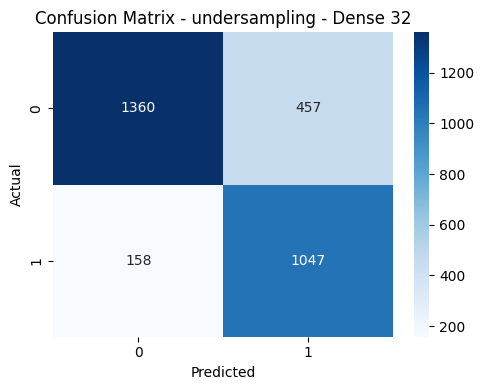

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: undersample, Dense: 32
dense_units = 32
strategy = "undersample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/undersampling_dense32_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: undersampling | Dense: 32")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - undersampling - Dense 32")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 64

Epoch 1/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6949 - f1: 0.6293 - loss: 1.4412 - precision_30: 0.6871 - recall_30: 0.5835
Epoch 1: val_f1 improved from -inf to 0.12634, saving model to models/3-layers/undersampling_dense64_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.6951 - f1: 0.6295 - loss: 1.4396 - precision_30: 0.6874 - recall_30: 0.5836 - val_accuracy: 0.0674 - val_f1: 0.1263 - val_loss: 5.0936 - val_precision_30: 1.0000 - val_recall_30: 0.0674 - learning_rate: 0.0010
Epoch 2/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7977 - f1: 0.7399 - loss: 0.8117 - precision_30: 0.8455 - recall_30: 0.6586
Epoch 2: val_f1 improved from 0.12634 to 0.77820, saving model to models/3-layers/undersampling_dense64_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7979 - f1: 0.7402 - loss: 0.8111 - precision_30: 0.8457 - recall_30: 0.6589 - val_accuracy: 0.6369 - val_f1: 0.7782 - val_loss: 1.0043 - val_precision_30: 1.0000 - val_recall_30: 0.6369 - learning_rate: 0.0010
Epoch 3/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8389 - f1: 0.8028 - loss: 0.6702 - precision_30: 0.8816 - recall_30: 0.7376
Epoch 3: val_f1 improved from 0.77820 to 0.83925, saving model to models/3-layers/undersampling_dense64_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8388 - f1: 0.8028 - loss: 0.6703 - precision_30: 0.8815 - recall_30: 0.7376 - val_accuracy: 0.7230 - val_f1: 0.8393 - val_loss: 1.2354 - val_precision_30: 1.0000 - val_recall_30: 0.7230 - learning_rate: 0.0010
Epoch 4/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8556 - f1: 0.8278 - loss: 0.6894 - precision_30: 0.8856 - recall_30: 0.7772
Epoch 4: val_f1 improved from 0.83925 to 0.93949, saving model to models/3-layers/undersampling_dense64_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8556 - f1: 0.8277 - loss: 0.6894 - precision_30: 0.8855 - recall_30: 0.7771 - val_accuracy: 0.8859 - val_f1: 0.9395 - val_loss: 0.5453 - val_precision_30: 1.0000 - val_recall_30: 0.8859 - learning_rate: 0.0010
Epoch 5/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8669 - f1: 0.8442 - loss: 0.6874 - precision_30: 0.8962 - recall_30: 0.7981
Epoch 5: val_f1 did not improve from 0.93949
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8669 - f1: 0.8441 - loss: 0.6876 - precision_30: 0.8962 - recall_30: 0.7979 - val_accuracy: 0.8371 - val_f1: 0.9113 - val_loss: 0.7184 - val_precision_30: 1.0000 - val_recall_30: 0.8371 - learning_rate: 0.0010
Epoch 6/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8868 - f1: 0.8678 - loss: 0.6004 - precision_30: 0.9197 - recall_30: 0.8214
Epoch 6: val_f1 did not improve from 0.93949
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8867 - f1: 0.8675 - loss: 0.6007 -

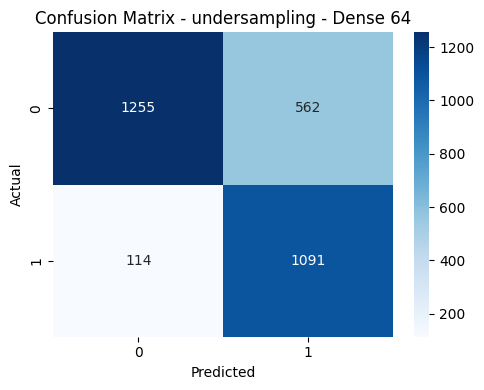

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: undersample, Dense: 64
dense_units = 64
strategy = "undersample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/undersampling_dense64_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: undersampling | Dense: 64")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - undersampling - Dense 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 128

Epoch 1/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6799 - f1: 0.5991 - loss: 2.7556 - precision_32: 0.6791 - recall_32: 0.5384
Epoch 1: val_f1 improved from -inf to 0.16556, saving model to models/3-layers/undersampling_dense128_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.6801 - f1: 0.5993 - loss: 2.7511 - precision_32: 0.6793 - recall_32: 0.5386 - val_accuracy: 0.0902 - val_f1: 0.1656 - val_loss: 2.6882 - val_precision_32: 1.0000 - val_recall_32: 0.0902 - learning_rate: 0.0010
Epoch 2/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7874 - f1: 0.7308 - loss: 0.9195 - precision_32: 0.8257 - recall_32: 0.6565
Epoch 2: val_f1 improved from 0.16556 to 0.81281, saving model to models/3-layers/undersampling_dense128_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7875 - f1: 0.7310 - loss: 0.9190 - precision_32: 0.8257 - recall_32: 0.6569 - val_accuracy: 0.6846 - val_f1: 0.8128 - val_loss: 0.9774 - val_precision_32: 1.0000 - val_recall_32: 0.6846 - learning_rate: 0.0010
Epoch 3/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8263 - f1: 0.7916 - loss: 0.7536 - precision_32: 0.8578 - recall_32: 0.7352
Epoch 3: val_f1 did not improve from 0.81281
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8263 - f1: 0.7916 - loss: 0.7535 - precision_32: 0.8577 - recall_32: 0.7353 - val_accuracy: 0.5394 - val_f1: 0.7008 - val_loss: 1.2916 - val_precision_32: 1.0000 - val_recall_32: 0.5394 - learning_rate: 0.0010
Epoch 4/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8283 - f1: 0.7958 - loss: 0.7573 - precision_32: 0.8676 - recall_32: 0.7375
Epoch 4: val_f1 did not improve from 0.81281
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8284 - f1: 0.7958 - loss: 0.7577 -

272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8529 - f1: 0.8192 - loss: 0.7568 - precision_32: 0.8899 - recall_32: 0.7604 - val_accuracy: 0.8133 - val_f1: 0.8970 - val_loss: 0.7814 - val_precision_32: 1.0000 - val_recall_32: 0.8133 - learning_rate: 5.0000e-04
Epoch 6/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8945 - f1: 0.8787 - loss: 0.5720 - precision_32: 0.9174 - recall_32: 0.8432
Epoch 6: val_f1 did not improve from 0.89703
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8945 - f1: 0.8786 - loss: 0.5720 - precision_32: 0.9174 - recall_32: 0.8431 - val_accuracy: 0.8091 - val_f1: 0.8945 - val_loss: 0.7336 - val_precision_32: 1.0000 - val_recall_32: 0.8091 - learning_rate: 5.0000e-04
Epoch 7/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9095 - f1: 0.8960 - loss: 0.5222 - precision_32: 0.9246 - recall_32: 0.8692
Epoch 7: val_f1 did not improve from 0.89703
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9094 - f1: 0.8959 - loss: 

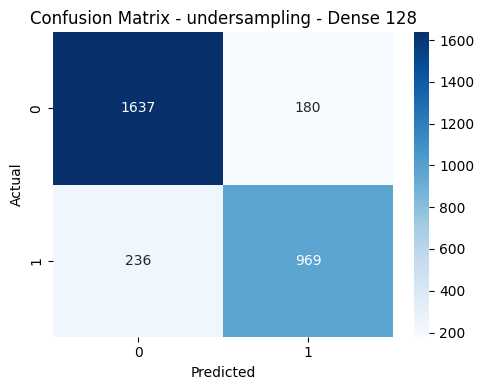

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: undersample, Dense: 128
dense_units = 128
strategy = "undersample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/undersampling_dense128_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: undersampling | Dense: 128")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - undersampling - Dense 128")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 🔩 Dense Units: 256

Epoch 1/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7116 - f1: 0.6609 - loss: 3.5520 - precision_34: 0.6909 - recall_34: 0.6345
Epoch 1: val_f1 improved from -inf to 0.69993, saving model to models/3-layers/undersampling_dense256_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7118 - f1: 0.6611 - loss: 3.5463 - precision_34: 0.6911 - recall_34: 0.6346 - val_accuracy: 0.5384 - val_f1: 0.6999 - val_loss: 1.6690 - val_precision_34: 1.0000 - val_recall_34: 0.5384 - learning_rate: 0.0010
Epoch 2/100
270/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8217 - f1: 0.7819 - loss: 1.0737 - precision_34: 0.8385 - recall_34: 0.7327
Epoch 2: val_f1 improved from 0.69993 to 0.86788, saving model to models/3-layers/undersampling_dense256_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8218 - f1: 0.7820 - loss: 1.0731 - precision_34: 0.8385 - recall_34: 0.7329 - val_accuracy: 0.7666 - val_f1: 0.8679 - val_loss: 1.0840 - val_precision_34: 1.0000 - val_recall_34: 0.7666 - learning_rate: 0.0010
Epoch 3/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8550 - f1: 0.8320 - loss: 0.8957 - precision_34: 0.8588 - recall_34: 0.8072
Epoch 3: val_f1 did not improve from 0.86788
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8548 - f1: 0.8318 - loss: 0.8964 - precision_34: 0.8587 - recall_34: 0.8068 - val_accuracy: 0.5477 - val_f1: 0.7078 - val_loss: 1.9432 - val_precision_34: 1.0000 - val_recall_34: 0.5477 - learning_rate: 0.0010
Epoch 4/100
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8541 - f1: 0.8278 - loss: 1.0840 - precision_34: 0.8744 - recall_34: 0.7868
Epoch 4: val_f1 improved from 0.86788 to 0.87907, saving model to models/3-layers/undersampling_dense256_best_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8541 - f1: 0.8278 - loss: 1.0837 - precision_34: 0.8743 - recall_34: 0.7869 - val_accuracy: 0.7842 - val_f1: 0.8791 - val_loss: 1.1027 - val_precision_34: 1.0000 - val_recall_34: 0.7842 - learning_rate: 0.0010
Epoch 5/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8859 - f1: 0.8651 - loss: 0.8468 - precision_34: 0.9034 - recall_34: 0.8303
Epoch 5: val_f1 did not improve from 0.87907
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8859 - f1: 0.8651 - loss: 0.8466 - precision_34: 0.9034 - recall_34: 0.8303 - val_accuracy: 0.6981 - val_f1: 0.8222 - val_loss: 1.3720 - val_precision_34: 1.0000 - val_recall_34: 0.6981 - learning_rate: 5.0000e-04
Epoch 6/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9222 - f1: 0.9088 - loss: 0.6787 - precision_34: 0.9385 - recall_34: 0.8815
Epoch 6: val_f1 did not improve from 0.87907
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9222 - f1: 0.9088 - loss: 0.67

272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9488 - f1: 0.9397 - loss: 0.5937 - precision_34: 0.9626 - recall_34: 0.9181 - val_accuracy: 0.8257 - val_f1: 0.9045 - val_loss: 0.8480 - val_precision_34: 1.0000 - val_recall_34: 0.8257 - learning_rate: 2.5000e-04
Epoch 8/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9717 - f1: 0.9673 - loss: 0.4559 - precision_34: 0.9761 - recall_34: 0.9588
Epoch 8: val_f1 did not improve from 0.90455
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9717 - f1: 0.9673 - loss: 0.4559 - precision_34: 0.9761 - recall_34: 0.9588 - val_accuracy: 0.8008 - val_f1: 0.8894 - val_loss: 0.9447 - val_precision_34: 1.0000 - val_recall_34: 0.8008 - learning_rate: 2.5000e-04
Epoch 9/100
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9828 - f1: 0.9803 - loss: 0.3928 - precision_34: 0.9824 - recall_34: 0.9783
Epoch 9: val_f1 did not improve from 0.90455
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9828 - f1: 0.9803 - loss: 

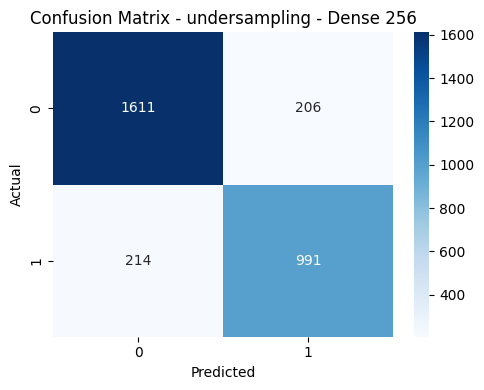

In [ ]:

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
from keras import backend as K

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

f1_metric = F1Score(name='f1')

# ✅ Config for Strategy: undersample, Dense: 256
dense_units = 256
strategy = "undersample"
dropout_rate = 0.3
l2_strength = 0.001

# Prepare training data
X_mod, y_mod = X_train.copy(), y_train.copy()

if strategy == "oversample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomOverSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res
elif strategy == "undersample":
    X_flat = X_mod.reshape(X_mod.shape[0], -1)
    X_res, y_res = RandomUnderSampler().fit_resample(X_flat, y_mod)
    X_mod = X_res.reshape(-1, 12, 5000, 1)
    y_mod = y_res

# Compute class weights for weighted strategy
class_weights = None
if strategy == "weighted":
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_mod), y=y_mod)
    class_weights = dict(enumerate(weights))

# Build and compile model
model = build_2d_cnn(input_shape=(12, 5000, 1), dropout_rate=dropout_rate, l2_strength=l2_strength, dense_units=dense_units)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), f1_metric])

# Callbacks
checkpoint_path = f"models/3-layers/undersampling_dense256_best_model.h5"
callbacks = [
    EarlyStopping(monitor='val_f1', patience=3, mode="max", restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode="max", verbose=1, save_best_only=True)
]

# Train
history = model.fit(
    X_mod, y_mod,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
loss, acc, precision, recall, f1_score_val = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_metric = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Strategy: undersampling | Dense: 256")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_metric:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Loss     : {loss:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - undersampling - Dense 256")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()